In [ ]:
import subprocess, sys

def pip_install(pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pkgs])

subprocess.call([sys.executable, "-m", "pip", "uninstall", "-y", "-q", "torchao"])

pip_install([
    "datasets>=3.0.0",
    "transformers>=4.46.0",
    "trl>=0.12.0",
    "peft>=0.13.0",
    "accelerate>=1.0.0",
    "bitsandbytes",
    "matplotlib",
    "pandas",
])

import os, re, json, math, random, itertools, warnings
import pandas as pd
import matplotlib.pyplot as plt
import torch
from collections import Counter
from datasets import load_dataset, Dataset

warnings.filterwarnings("ignore")
random.seed(42)
torch.manual_seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

DATASET_ID = "SupraLabs/reasoning-corpus-4K-5M-v1"

SAMPLE_SIZE = 8_000

print(f"\nStreaming {DATASET_ID} ...")
stream = load_dataset(DATASET_ID, split="train", streaming=True)

stream = stream.shuffle(seed=42, buffer_size=30_000)

rows = list(itertools.islice(stream, SAMPLE_SIZE))
ds = Dataset.from_list(rows)
print(f"Materialized sample: {len(ds):,} rows")
print(f"Columns: {ds.column_names}")

ex = ds[0]
print("\n" + "=" * 70)
print("EXAMPLE ROW")
print("=" * 70)
print(f"repo_id : {ex['repo_id']}")
print(f"tok_len : {ex['tok_len']}")
print(f"user            : {ex['user'][:300]} ...")
print(f"thought_trace   : {ex['thought_trace'][:300]} ...")
print(f"assistant       : {ex['assistant'][:300]} ...")

In [ ]:
df = ds.to_pandas()

print("\nTop 15 source repos in sample:")
src_counts = df["repo_id"].value_counts()
print(src_counts.head(15).to_string())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df["tok_len"], bins=60, color="#4C72B0", edgecolor="white")
axes[0, 0].set_title("Token length distribution")
axes[0, 0].set_xlabel("tok_len"); axes[0, 0].set_ylabel("rows")

src_counts.head(12).plot(kind="barh", ax=axes[0, 1], color="#55A868")
axes[0, 1].invert_yaxis()
axes[0, 1].set_title("Top-12 source repos (sample)")

df["think_chars"] = df["thought_trace"].str.len()
df["answer_chars"] = df["assistant"].str.len()
df["reason_ratio"] = df["think_chars"] / (df["think_chars"] + df["answer_chars"] + 1)

axes[1, 0].hist(df["reason_ratio"], bins=50, color="#C44E52", edgecolor="white")
axes[1, 0].set_title("Reasoning ratio  (think / (think + answer))")
axes[1, 0].set_xlabel("ratio")

axes[1, 1].scatter(df["tok_len"], df["reason_ratio"], s=4, alpha=0.25, color="#8172B2")
axes[1, 1].set_title("tok_len vs reasoning ratio")
axes[1, 1].set_xlabel("tok_len"); axes[1, 1].set_ylabel("ratio")

plt.tight_layout()
plt.show()

print("\nSummary stats:")
print(df[["tok_len", "think_chars", "answer_chars", "reason_ratio"]]
      .describe().round(2).to_string())

def tag_task(row):
    u = row["user"].lower()
    a = row["assistant"]
    if "```" in a or re.search(r"\b(def |class |import |function|#include)", a):
        return "code"
    if re.search(r"(prove|equation|integral|theorem|\\frac|\\int|solve for)", u):
        return "math"
    if re.search(r"\b(patient|diagnosis|symptom|treatment|clinical)\b", u):
        return "medical"
    if re.search(r"\b(which of the following|options?:|\(a\)|\(b\))", u):
        return "mcq/logic"
    return "general"

df["task"] = df.apply(tag_task, axis=1)
print("\nHeuristic task mix:")
print(df["task"].value_counts(normalize=True).round(3).to_string())

In [ ]:
def filter_length(row, min_tok=200, max_tok=3000):
    """Keep samples within a training-friendly token budget."""
    return min_tok <= row["tok_len"] <= max_tok

def filter_degenerate(row):
    """Drop empty/near-empty thoughts or answers."""
    return len(row["thought_trace"]) > 100 and len(row["assistant"]) > 20

def filter_repetition(row, max_line_repeat=0.30):
    """Drop traces where one line repeats too often (looping models)."""
    lines = [l.strip() for l in row["thought_trace"].split("\n") if l.strip()]
    if len(lines) < 5:
        return True
    most_common = Counter(lines).most_common(1)[0][1]
    return (most_common / len(lines)) <= max_line_repeat

def filter_reason_ratio(row, lo=0.15, hi=0.97):
    """Keep samples that actually reason but don't ONLY reason."""
    t, a = len(row["thought_trace"]), len(row["assistant"])
    r = t / (t + a + 1)
    return lo <= r <= hi

n0 = len(ds)
ds_f = ds.filter(filter_length)
ds_f = ds_f.filter(filter_degenerate)
ds_f = ds_f.filter(filter_repetition)
ds_f = ds_f.filter(filter_reason_ratio)
print(f"\nFiltering: {n0:,} -> {len(ds_f):,} rows "
      f"({100 * len(ds_f) / n0:.1f}% retained)")

MODEL_ID = "HuggingFaceTB/SmolLM2-135M-Instruct"

from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

SYSTEM_PROMPT = (
    "You are a careful reasoning assistant. Think step by step inside "
    "<think>...</think> tags, then give your final answer."
)

def to_chat(row):
    return {
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": row["user"]},
            {"role": "assistant",
             "content": f"<think>\n{row['thought_trace']}\n</think>\n\n{row['assistant']}"},
        ]
    }

train_ds = ds_f.map(to_chat, remove_columns=ds_f.column_names)

train_ds = train_ds.shuffle(seed=42)
N_TRAIN, N_EVAL = 1_500, 100
eval_ds = train_ds.select(range(N_TRAIN, min(N_TRAIN + N_EVAL, len(train_ds))))
train_ds = train_ds.select(range(min(N_TRAIN, len(train_ds))))
print(f"\nTrain: {len(train_ds):,}  |  Eval: {len(eval_ds):,}")

print("\nRendered training sample (truncated):")
print(tokenizer.apply_chat_template(train_ds[0]["messages"], tokenize=False)[:800])

In [ ]:
from trl import SFTTrainer, SFTConfig
from peft import LoraConfig

try:
    import peft.import_utils as _piu
    import peft.tuners.lora.torchao as _plt
    _piu.is_torchao_available = lambda: False
    _plt.is_torchao_available = lambda: False
except Exception:
    pass

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype=torch.bfloat16 if DEVICE == "cuda" else torch.float32,
).to(DEVICE)

peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
)

sft_config = SFTConfig(
    output_dir="smollm2-reasoning-demo",
    max_length=2048,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    num_train_epochs=1,
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_steps=10,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="no",
    bf16=(DEVICE == "cuda"),
    gradient_checkpointing=True,
    report_to="none",
)

trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    peft_config=peft_config,
    processing_class=tokenizer,
)

print("\nStarting fine-tune (≈10–20 min on a T4 with these settings)...")
trainer.train()
print("Done. Final eval loss:", trainer.evaluate().get("eval_loss"))

Device: cuda
GPU: Tesla T4

Streaming SupraLabs/reasoning-corpus-4K-5M-v1 ...
Materialized sample: 8,000 rows
Columns: ['repo_id', 'tok_len', 'user', 'thought_trace', 'assistant', 'ChatML']

EXAMPLE ROW
repo_id : Magpie-Reasoning-V2-250K-CoT-Deepseek-R1-Llama-70B
tok_len : 4224
user            : A sample of size n = 100 is taken from a large population and the sample mean is found to be 13. If it is known that the population standard deviation is 3, what is the probability that the sample mean will be between 12 and 14? ...
thought_trace   : Okay, so I have this problem here where a sample of size n = 100 is taken from a large population. The sample mean is 13, and the population standard deviation is 3. I need to find the probability that the sample mean will be between 12 and 14. Hmm, let me think about how to approach this.

First, I ...
assistant       : Given a sample of size \( n = 100 \) taken from a large population with a sample mean of 13 and a population standard deviation o

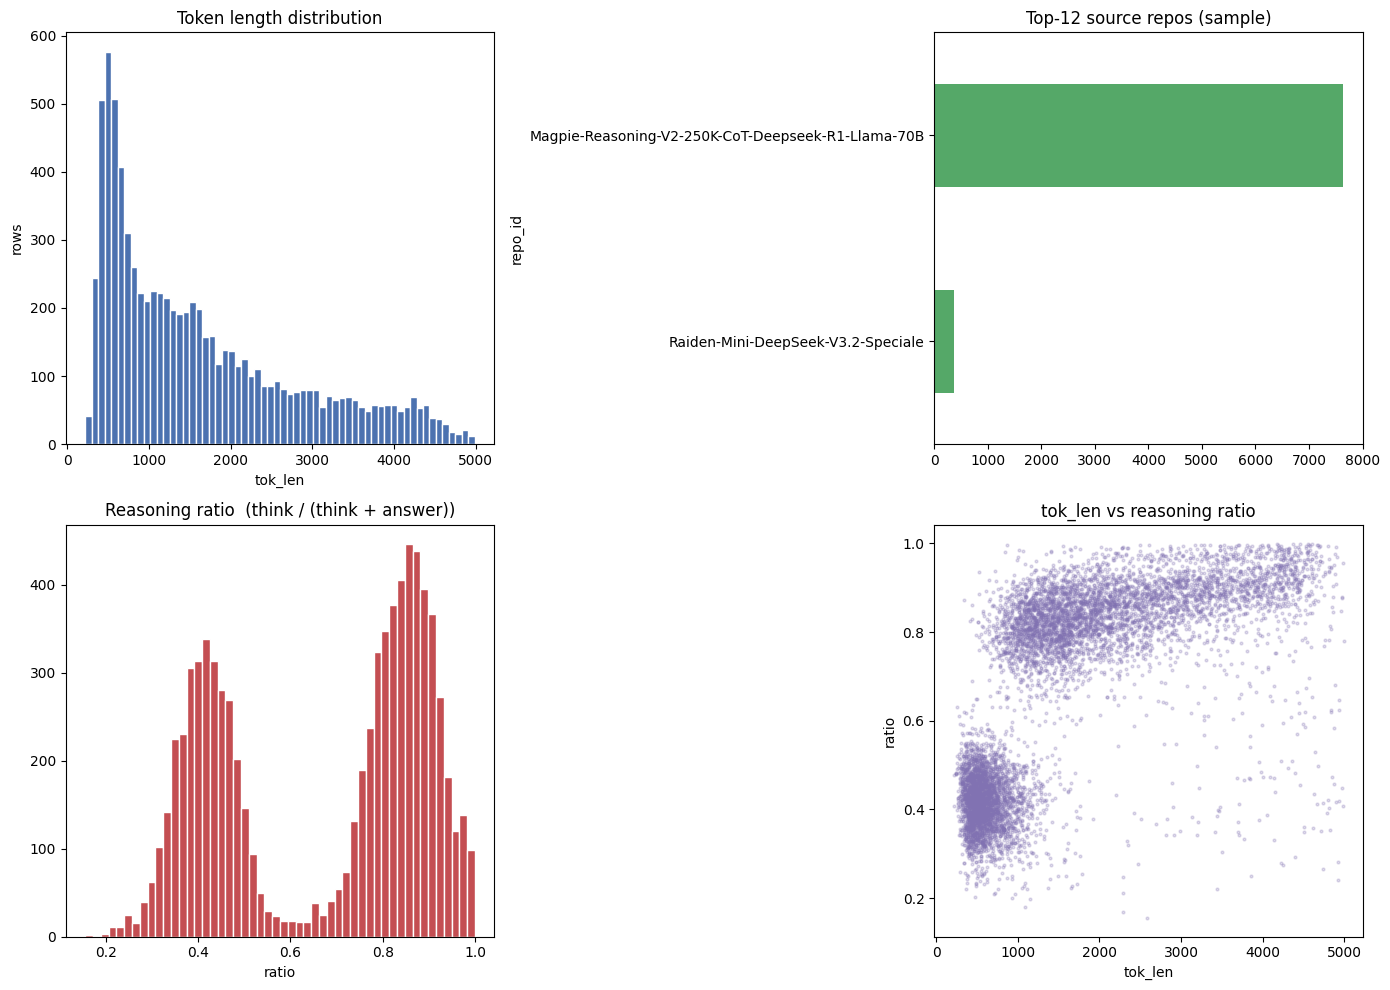


Summary stats:
       tok_len  think_chars  answer_chars  reason_ratio
count  8000.00      8000.00       8000.00       8000.00
mean   1626.85      3783.09        975.23          0.67
std    1175.33      3598.41        931.75          0.22
min     217.00       116.00          3.00          0.16
25%     637.00       633.00        607.75          0.43
50%    1274.00      3009.00        816.00          0.77
75%    2300.00      5608.00       1080.00          0.86
max    4992.00     19460.00      13619.00          1.00

Heuristic task mix:
task
general      0.728
math         0.133
code         0.104
mcq/logic    0.031
medical      0.005


Filter:   0%|          | 0/8000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/6742 [00:00<?, ? examples/s]

Filter:   0%|          | 0/6740 [00:00<?, ? examples/s]

Filter:   0%|          | 0/6740 [00:00<?, ? examples/s]

...

Tokenizing eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

Building labels for eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]


Starting fine-tune (≈10–20 min on a T4 with these settings)...


Step,Training Loss,Validation Loss


In [ ]:
def generate(question, max_new_tokens=512, temperature=0.7):
    msgs = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": question},
    ]
    prompt = tokenizer.apply_chat_template(
        msgs, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        out = trainer.model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            top_p=0.9,
            do_sample=True,
            pad_token_id=tokenizer.pad_token_id,
        )
    text = tokenizer.decode(out[0][inputs["input_ids"].shape[1]:],
                            skip_special_tokens=True)
    m = re.search(r"<think>(.*?)</think>(.*)", text, re.DOTALL)
    if m:
        print("─" * 60, "\nTHINKING:\n", m.group(1).strip()[:1500])
        print("─" * 60, "\nANSWER:\n", m.group(2).strip())
    else:
        print(text)

print("\n\n### TEST 1: logic puzzle")
generate("If all bloops are razzies and all razzies are lazzies, "
         "are all bloops definitely lazzies? Explain briefly.")

print("\n\n### TEST 2: quick math")
generate("A train travels 180 km in 2.5 hours. What is its average speed in km/h?")

train_ds.to_parquet("reasoning_subset_train.parquet")
eval_ds.to_parquet("reasoning_subset_eval.parquet")
print("\nSaved: reasoning_subset_train.parquet / reasoning_subset_eval.parquet")